# Lab 1 — Model Comparison

Side-by-side evaluation of all four sentiment classifiers — **ANN**, **BiLSTM**, **DistilBERT**, and **RoBERTa** â€” across three datasets of increasing scale and complexity.

| Dataset | Task | Test samples |
|---------|------|--------------|
| 1K | Binary sentiment (Negative / Positive) | 100 |
| 25K | Binary sentiment (Negative / Positive) | 2 500 |
| Video Games (VG) | 5-class star rating (1-5) | ~256 K |

Each dataset section shows per-model classification reports, a comparison table (Accuracy, Macro F1, Weighted F1), and confusion matrices. An overall summary table at the end collects all 12 results.

## Setup & Imports

In [1]:
import contextlib
import io

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from data_loading_code import preprocess_pandas
from transformer_utils import (
    build_tf_datasets,
    compute_metrics_tf,
    evaluate_tf,
    plot_confusion_matrix_tf,
)
from utils import (
    device_check,
    validate,
    plot_confusion_matrix,
    load_ann_run,
    load_bilstm_run,
)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR  = NOTEBOOK_DIR.parent
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
MODELS_DIR   = PROJECT_DIR / 'models'
MAX_LENGTH   = 128

DISTILBERT_NAME = 'distilbert-base-uncased'
ROBERTA_NAME    = 'roberta-base'

tokenizer_distilbert = AutoTokenizer.from_pretrained(DISTILBERT_NAME)
tokenizer_roberta    = AutoTokenizer.from_pretrained(ROBERTA_NAME)

In [3]:
test_1k  = pd.read_csv(SPLITS_DIR / '1k_test.csv')
test_25k = pd.read_csv(SPLITS_DIR / '25k_test.csv')
test_vg  = pd.read_csv(SPLITS_DIR / 'vg_test.csv')
# Remap VG labels 1-5 -> 0-4
test_vg['Class'] = test_vg['Class'].astype(int) - 1

## Helper functions

Preprocessing, encoding, and evaluation wrappers so each dataset section stays concise.

In [4]:
def preprocess_seq(df: pd.DataFrame) -> pd.DataFrame:
    """Lightweight text cleaning for the BiLSTM (keeps stopwords)."""
    df = df.copy()
    s = df['Sentence'].str.lower()
    s = s.str.replace(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', '', regex=True)
    s = s.str.replace(r'(?:\d{1,3}\.){3}\d{1,3}', '', regex=True)
    s = s.str.replace(r'[^\w\s]', ' ', regex=True)
    s = s.str.replace(r'\d+', ' ', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    df['Sentence'] = s
    return df


def encode_corpus(texts, vocab, max_len):
    return torch.tensor(
        [vocab.encode(t, max_len) for t in texts],
        dtype=torch.long,
    )


def eval_ann(model, vectorizer, svd, test_df, batch_size=512):
    """Preprocess → TF-IDF → SVD → DataLoader → validate. Returns (y_true, y_pred)."""
    test_proc = preprocess_pandas(test_df.copy())
    X_tfidf   = vectorizer.transform(test_proc['Sentence'])
    X_svd     = svd.transform(X_tfidf)
    X_t       = torch.tensor(X_svd, dtype=torch.float32)
    y_t       = torch.tensor(test_df['Class'].values, dtype=torch.long)
    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    _, _, y_true, y_pred = validate(model, loader, nn.CrossEntropyLoss())
    return y_true, y_pred


def eval_bilstm(model, vocab, max_seq_len, test_df, batch_size=512):
    """Preprocess → encode → DataLoader → validate. Returns (y_true, y_pred)."""
    test_proc = preprocess_seq(test_df.copy())
    X_t       = encode_corpus(test_proc['Sentence'].tolist(), vocab, max_seq_len)
    y_t       = torch.tensor(test_df['Class'].values, dtype=torch.long)
    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    _, _, y_true, y_pred = validate(model, loader, nn.CrossEntropyLoss())
    return y_true, y_pred


def report(label, y_true, y_pred, class_names):
    """Print a sklearn classification report."""
    print(f"Classification Report: {label}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))


def compute_scores(name, y_true, y_pred):
    return {
        'Model':       name,
        'Accuracy':    accuracy_score(y_true, y_pred),
        'Macro F1':    f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def get_trainer(model):
    args = TrainingArguments(
        output_dir='tmp_eval',
        per_device_eval_batch_size=64,
        dataloader_num_workers=16,
        report_to='none',
    )
    return Trainer(model=model, args=args, compute_metrics=compute_metrics_tf)


def show_cm_grid(specs, ncols=2, cell_size=4):
    """Display confusion matrices in a grid.

    specs : list of tuples passed straight to plot_confusion_matrix_tf:
            (y_true, y_pred, num_classes, class_names, title[, normalize])
    """

    original_show = plt.show
    imgs = []

    def _capture():
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=200, bbox_inches='tight')
        buf.seek(0)
        imgs.append(mpimg.imread(buf))
        plt.close()

    plt.show = _capture
    try:
        for spec in specs:
            plot_confusion_matrix_tf(*spec)
    finally:
        plt.show = original_show

    nrows = (len(imgs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(cell_size * ncols, cell_size * nrows))
    axes_flat = np.array(axes).flat
    for ax, img in zip(axes_flat, imgs):
        ax.imshow(img)
        ax.axis('off')
    for ax in list(axes_flat)[len(imgs):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## Load all models

In [5]:
# ===== ANN =====
ann_model_1k,  ann_vec_1k,  ann_svd_1k  = load_ann_run(MODELS_DIR / 'ann_1k',  device)
ann_model_25k, ann_vec_25k, ann_svd_25k = load_ann_run(MODELS_DIR / 'ann_25k', device)
ann_model_vg,  ann_vec_vg,  ann_svd_vg  = load_ann_run(MODELS_DIR / 'ann_vg',  device)

In [6]:
# ===== BiLSTM =====
bilstm_model_1k,  bilstm_vocab_1k,  bilstm_maxlen_1k  = load_bilstm_run(MODELS_DIR / 'bilstm_1k',  device)
bilstm_model_25k, bilstm_vocab_25k, bilstm_maxlen_25k = load_bilstm_run(MODELS_DIR / 'bilstm_25k', device)
bilstm_model_vg,  bilstm_vocab_vg,  bilstm_maxlen_vg  = load_bilstm_run(MODELS_DIR / 'bilstm_vg',  device)

In [7]:
# ===== DistilBERT =====
distilbert_1k  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'distilbert_1k').to(device)
distilbert_25k = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'distilbert_25k').to(device)
distilbert_vg  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'distilbert_vg').to(device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [8]:
# ===== RoBERTa =====
roberta_1k  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'roberta_1k').to(device)
roberta_25k = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'roberta_25k').to(device)
roberta_vg  = AutoModelForSequenceClassification.from_pretrained(MODELS_DIR / 'roberta_vg').to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## Build transformer test datasets

One tokenized dataset per (model family, split). The same test DataFrame is passed
for all three slots — only the `'test'` key is used.

In [9]:
def build_test_ds(test_df, tokenizer):
    return build_tf_datasets(
        train_df=test_df, val_df=test_df, test_df=test_df,
        tokenizer=tokenizer, text_col='Sentence', label_col='Class',
        max_length=MAX_LENGTH,
    )['test']

ds_1k_distil   = build_test_ds(test_1k,  tokenizer_distilbert)
ds_25k_distil  = build_test_ds(test_25k, tokenizer_distilbert)
ds_vg_distil   = build_test_ds(test_vg,  tokenizer_distilbert)

ds_1k_roberta  = build_test_ds(test_1k,  tokenizer_roberta)
ds_25k_roberta = build_test_ds(test_25k, tokenizer_roberta)
ds_vg_roberta  = build_test_ds(test_vg,  tokenizer_roberta)

---
# 1K Dataset

All four models trained on the 1 K Amazon review split, evaluated on `1k_test.csv` (100 samples, binary).

In [10]:
CLASS_NAMES_BIN = ['Negative', 'Positive']

# ANN
with contextlib.redirect_stdout(io.StringIO()):
    y_true_ann_1k, y_pred_ann_1k = eval_ann(ann_model_1k, ann_vec_1k, ann_svd_1k, test_1k)

# BiLSTM
with contextlib.redirect_stdout(io.StringIO()):
    y_true_bilstm_1k, y_pred_bilstm_1k = eval_bilstm(bilstm_model_1k, bilstm_vocab_1k, bilstm_maxlen_1k, test_1k)

# DistilBERT
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_distil_1k, y_pred_distil_1k = evaluate_tf(
        get_trainer(distilbert_1k), ds_1k_distil,
        label='DistilBERT — 1K', class_names=CLASS_NAMES_BIN,
    )

# RoBERTa
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_roberta_1k, y_pred_roberta_1k = evaluate_tf(
        get_trainer(roberta_1k), ds_1k_roberta,
        label='RoBERTa — 1K', class_names=CLASS_NAMES_BIN,
    )

In [11]:
results_1k = [
    compute_scores('ANN',        y_true_ann_1k,    y_pred_ann_1k),
    compute_scores('BiLSTM',     y_true_bilstm_1k, y_pred_bilstm_1k),
    compute_scores('DistilBERT', y_true_distil_1k, y_pred_distil_1k),
    compute_scores('RoBERTa',    y_true_roberta_1k, y_pred_roberta_1k),
]
df_1k = pd.DataFrame(results_1k).set_index('Model')
df_1k.style.format('{:.4f}').highlight_max(axis=0, props='font-weight: bold; color: #1a7f3c')

,Accuracy,Macro F1,Weighted F1
Model,,,
ANN,0.7400,0.7383,0.7383
BiLSTM,0.7200,0.7190,0.7190
DistilBERT,0.9400,0.9400,0.9400
RoBERTa,0.9500,0.9500,0.9500


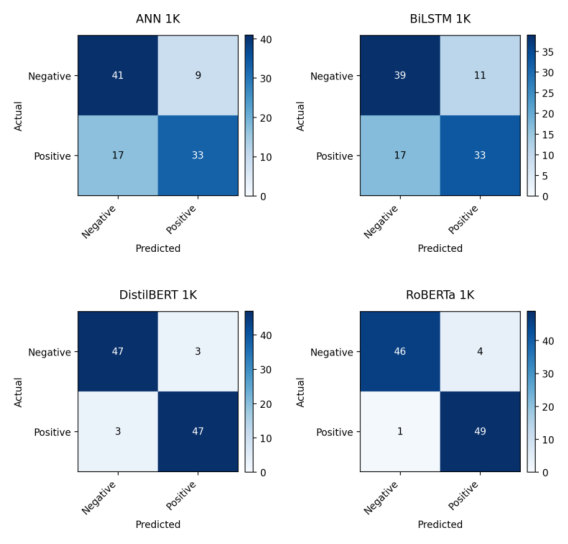

In [12]:
show_cm_grid([
    (y_true_ann_1k,     y_pred_ann_1k,     2, CLASS_NAMES_BIN, 'ANN 1K'),
    (y_true_bilstm_1k,  y_pred_bilstm_1k,  2, CLASS_NAMES_BIN, 'BiLSTM 1K'),
    (y_true_distil_1k,  y_pred_distil_1k,  2, CLASS_NAMES_BIN, 'DistilBERT 1K'),
    (y_true_roberta_1k, y_pred_roberta_1k, 2, CLASS_NAMES_BIN, 'RoBERTa 1K'),
])

---
# 25K Dataset

All four models trained on the 25 K Amazon review split, evaluated on `25k_test.csv` (2 500 samples, binary).

In [13]:
# ANN
with contextlib.redirect_stdout(io.StringIO()):
    y_true_ann_25k, y_pred_ann_25k = eval_ann(ann_model_25k, ann_vec_25k, ann_svd_25k, test_25k)

# BiLSTM
with contextlib.redirect_stdout(io.StringIO()):
    y_true_bilstm_25k, y_pred_bilstm_25k = eval_bilstm(bilstm_model_25k, bilstm_vocab_25k, bilstm_maxlen_25k, test_25k)

# DistilBERT
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_distil_25k, y_pred_distil_25k = evaluate_tf(
        get_trainer(distilbert_25k), ds_25k_distil,
        label='DistilBERT — 25K', class_names=CLASS_NAMES_BIN,
    )

# RoBERTa
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_roberta_25k, y_pred_roberta_25k = evaluate_tf(
        get_trainer(roberta_25k), ds_25k_roberta,
        label='RoBERTa — 25K', class_names=CLASS_NAMES_BIN,
    )

In [14]:
results_25k = [
    compute_scores('ANN',        y_true_ann_25k,    y_pred_ann_25k),
    compute_scores('BiLSTM',     y_true_bilstm_25k, y_pred_bilstm_25k),
    compute_scores('DistilBERT', y_true_distil_25k, y_pred_distil_25k),
    compute_scores('RoBERTa',    y_true_roberta_25k, y_pred_roberta_25k),
]
df_25k = pd.DataFrame(results_25k).set_index('Model')
df_25k.style.format('{:.4f}').highlight_max(axis=0, props='font-weight: bold; color: #1a7f3c')

,Accuracy,Macro F1,Weighted F1
Model,,,
ANN,0.8448,0.8386,0.8452
BiLSTM,0.8740,0.8678,0.8738
DistilBERT,0.9304,0.9273,0.9305
RoBERTa,0.9440,0.9414,0.9440


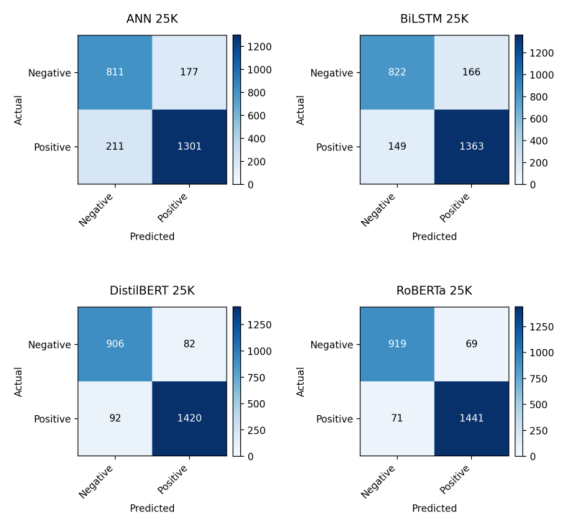

In [15]:
show_cm_grid([
    (y_true_ann_25k,    y_pred_ann_25k,    2, CLASS_NAMES_BIN, 'ANN 25K'),
    (y_true_bilstm_25k, y_pred_bilstm_25k, 2, CLASS_NAMES_BIN, 'BiLSTM 25K'),
    (y_true_distil_25k, y_pred_distil_25k, 2, CLASS_NAMES_BIN, 'DistilBERT 25K'),
    (y_true_roberta_25k, y_pred_roberta_25k, 2, CLASS_NAMES_BIN, 'RoBERTa 25K'),
])

---
# Video Games Dataset

All four models trained on the Video Games split, evaluated on `vg_test.csv` (~256 K samples, 5-class star rating).

In [16]:
CLASS_NAMES_VG = ['1-star', '2-star', '3-star', '4-star', '5-star']

# ANN
with contextlib.redirect_stdout(io.StringIO()):
    y_true_ann_vg, y_pred_ann_vg = eval_ann(ann_model_vg, ann_vec_vg, ann_svd_vg, test_vg)

# BiLSTM
with contextlib.redirect_stdout(io.StringIO()):
    y_true_bilstm_vg, y_pred_bilstm_vg = eval_bilstm(bilstm_model_vg, bilstm_vocab_vg, bilstm_maxlen_vg, test_vg)

# DistilBERT
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_distil_vg, y_pred_distil_vg = evaluate_tf(
        get_trainer(distilbert_vg), ds_vg_distil,
        label='DistilBERT — VG', class_names=CLASS_NAMES_VG,
    )

# RoBERTa
with contextlib.redirect_stdout(io.StringIO()):
    _, y_true_roberta_vg, y_pred_roberta_vg = evaluate_tf(
        get_trainer(roberta_vg), ds_vg_roberta,
        label='RoBERTa — VG', class_names=CLASS_NAMES_VG,
    )

In [17]:
results_vg = [
    compute_scores('ANN',        y_true_ann_vg,    y_pred_ann_vg),
    compute_scores('BiLSTM',     y_true_bilstm_vg, y_pred_bilstm_vg),
    compute_scores('DistilBERT', y_true_distil_vg, y_pred_distil_vg),
    compute_scores('RoBERTa',    y_true_roberta_vg, y_pred_roberta_vg),
]
df_vg = pd.DataFrame(results_vg).set_index('Model')
df_vg.style.format('{:.4f}').highlight_max(axis=0, props='font-weight: bold; color: #1a7f3c')

,Accuracy,Macro F1,Weighted F1
Model,,,
ANN,0.6102,0.4847,0.6338
BiLSTM,0.6749,0.5554,0.6910
DistilBERT,0.6900,0.5879,0.7084
RoBERTa,0.7043,0.6031,0.7215


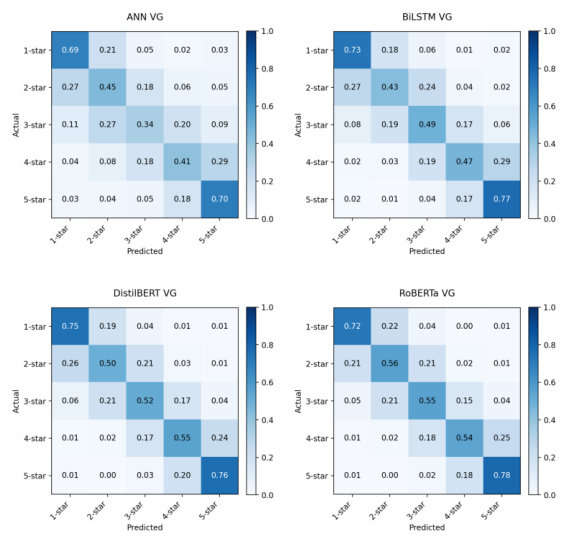

In [18]:
show_cm_grid([
    (y_true_ann_vg,     y_pred_ann_vg,     5, CLASS_NAMES_VG, 'ANN VG',        True),
    (y_true_bilstm_vg,  y_pred_bilstm_vg,  5, CLASS_NAMES_VG, 'BiLSTM VG',     True),
    (y_true_distil_vg,  y_pred_distil_vg,  5, CLASS_NAMES_VG, 'DistilBERT VG', True),
    (y_true_roberta_vg, y_pred_roberta_vg, 5, CLASS_NAMES_VG, 'RoBERTa VG',    True),
])